Inspect the CSV file to identify its columns, time coverage, countries, trade measures, and units. That will tell us which questions (Business Understanding) we can reasonably answer.

In [1]:
from pathlib import Path
from io import StringIO
import pandas as pd

# Locate the CSV whether the notebook runs from the project root
# or from the notebooks folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

csv_path = project_dir / "data" / "raw" / "FTD-mf.csv"
lines = csv_path.read_text(encoding="utf-8-sig").splitlines()


# Read one table from the Census file.
def read_section(name):
    start = lines.index(name) + 1
    end = start

    while end < len(lines) and lines[end].strip():
        end += 1

    return pd.read_csv(StringIO("\n".join(lines[start:end])))


periods = read_section("TIME PERIODS")
data = read_section("DATA")

# Keep US goods-only imports, exports, and trade balance.
goods = data.loc[
    (data["cat_idx"] == 2)
    & (data["geo_idx"] == 1)
    & (data["is_adj"] == 0)
    & (data["dt_idx"].isin([1, 2, 3]))
].copy()

goods["val"] = pd.to_numeric(goods["val"], errors="coerce")

goods = goods.merge(
    periods,
    on="per_idx",
    how="left",
    validate="many_to_one",
)

goods["date"] = pd.to_datetime(goods["per_name"], format="%b-%Y")

# Create one row per month, keeping only complete observations.
trade_df = (
    goods.pivot(index="date", columns="dt_idx", values="val")
    .rename(columns={
        1: "trade_balance",
        2: "exports",
        3: "imports",
    })
    .reindex(columns=["imports", "exports", "trade_balance"])
    .dropna(subset=["imports", "exports", "trade_balance"])
    .sort_index()
    .rename_axis(columns=None)
)

# All three measures are in millions of US dollars.
trade_df.head()

,imports,exports,trade_balance
date,,,
1992-01-01,40163,33953,-6210
1992-02-01,39228,36179,-3049
1992-03-01,43501,39061,-4440
1992-04-01,43180,36530,-6651
1992-05-01,42390,35996,-6394


In [2]:
trade_df.tail()

,imports,exports,trade_balance
date,,,
2026-03-01,304515,222677,-81837
2026-04-01,302940,220426,-82513
2026-05-01,314799,210713,-104086
2026-06-01,319770,209988,-109782
2026-07-01,335008,198909,-136099


In [3]:
trade_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 415 entries, 1992-01-01 to 2026-07-01
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   imports        415 non-null    int64
 1   exports        415 non-null    int64
 2   trade_balance  415 non-null    int64
dtypes: int64(3)
memory usage: 13.0 KB


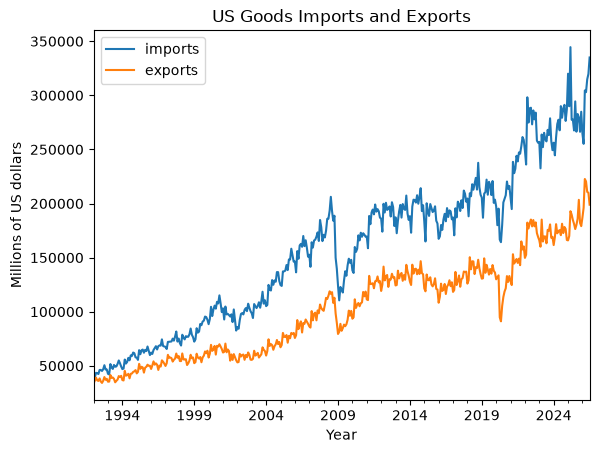

In [4]:
import matplotlib.pyplot as plt

trade_df[["imports", "exports"]].plot()

plt.xlabel("Year")
plt.ylabel("Millions of US dollars")
plt.title("US Goods Imports and Exports")
plt.show()

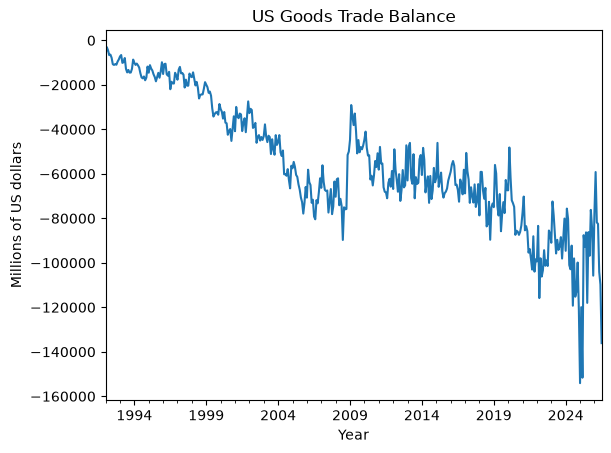

In [5]:
trade_df["trade_balance"].plot()

plt.xlabel("Year")
plt.ylabel("Millions of US dollars")
plt.title("US Goods Trade Balance")
plt.show()

In [6]:
trade_df["trump_second_term"] = (
    trade_df.index >= "2025-01-01"
).astype(int)

trade_df["trump_second_term"].value_counts().sort_index()

trump_second_term
0    396
1     19
Name: count, dtype: int64

In [7]:
# Percentage change compared with the same month one year earlier.
for column in ["imports", "exports"]:
    trade_df[f"{column}_yoy_pct"] = (
        trade_df[column].pct_change(periods=12, fill_method=None) * 100
    )

# Change in trade balance, in millions of US dollars.
trade_df["trade_balance_yoy_change"] = (
    trade_df["trade_balance"].diff(periods=12)
)

trade_df[
    ["imports_yoy_pct", "exports_yoy_pct", "trade_balance_yoy_change"]
].tail()

,imports_yoy_pct,exports_yoy_pct,trade_balance_yoy_change
date,,,
2026-03-01,-11.622582,15.426323,69807.0
2026-04-01,9.195506,16.104735,5065.0
2026-05-01,13.354074,13.983328,-11236.0
2026-06-01,19.515614,15.859923,-23470.0
2026-07-01,13.793092,12.761483,-18096.0


In [8]:
trade_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 415 entries, 1992-01-01 to 2026-07-01
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   imports                   415 non-null    int64  
 1   exports                   415 non-null    int64  
 2   trade_balance             415 non-null    int64  
 3   trump_second_term         415 non-null    int64  
 4   imports_yoy_pct           403 non-null    float64
 5   exports_yoy_pct           403 non-null    float64
 6   trade_balance_yoy_change  403 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 25.9 KB


In [9]:
analysis_df = trade_df.dropna(
    subset=[
        "imports_yoy_pct",
        "exports_yoy_pct",
        "trade_balance_yoy_change",
    ]
).copy()

analysis_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 403 entries, 1993-01-01 to 2026-07-01
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   imports                   403 non-null    int64  
 1   exports                   403 non-null    int64  
 2   trade_balance             403 non-null    int64  
 3   trump_second_term         403 non-null    int64  
 4   imports_yoy_pct           403 non-null    float64
 5   exports_yoy_pct           403 non-null    float64
 6   trade_balance_yoy_change  403 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 25.2 KB


In [10]:
# Save the complete, prepared dataset for use in the modeling notebook.
output_path = project_dir / "data" / "processed" / "analysis_data.csv"

analysis_df.to_csv(output_path, index=True, index_label="date")

print(f"Saved {len(analysis_df)} observations to:\n{output_path}")

Saved 403 observations to:
c:\Users\agbro\OneDrive\Desktop\Jupyter - VS Code\trump-tariffs-and-international-trade\data\processed\analysis_data.csv
